### Titanic Kaggle Competiion

##### Variable Definition Key 
survived Survival 0 = No, 1 = Yes \
pclass Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd \
sex male , female \
Age Age in years \
sibsp # of siblings / spouses aboard the Titanic \
parch # of parents / children aboard the Titanic \
ticket Ticket number \
fare Passenger fare \
cabin Cabin number \
embarked Port of Embarkation C = Cherbourg, Q = Queenstown, S = Southampton 

##### Variable Notes
pclass: A proxy for socio-economic status (SES) 1st = Upper 2nd = Middle 3rd = Lower \ 
Age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5 \ 
Sibsp: The dataset defines family relations in this way \
Sibling brother, sister, stepbrother, stepsister \ 
Spouse husband, wife (mistresses and fiancés were ignored) \

parch: The dataset defines family relations in this way \

Parent mother, father \
Child daughter, son, stepdaughter, stepson \
Some children travelled only with a nanny, therefore parch=0 for them \

Overview
1) Undertand the shape of the data 
2) Data Cleaning
3) Data Exploration
4) Feature Engineering 
5) Data Preprocessing for Model 
6) Basic Model Building
7) Model Tuning
8) Ensemble Modle Building
9) Results

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load the data
training = pd.read_csv("data/train.csv")
testing = pd.read_csv("data/test.csv")

training['train_test'] = 1
testing['train_test'] = 0

testing['Survived'] = np.nan
all_data = pd.concat([training,testing])

%matplotlib inline
all_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='str')

> temporarily combines 2 datasets so they can be processed in the same way.

#### Data Exploration

1) For Numeric data: 
- made histograms to understand distribution 
- corrplot ? 
- pivot table comparing survival rate across numeric valuse

2) For Categoriacal data: 
- made bar charts to udnerstand balance of classes 
- made pivot table to understand relatinoship with survival

In [3]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_test
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [4]:
#quick look at our data types and missing values
training.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


In [5]:
# to better understand numeric data
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.0


In [6]:
# quick way to separate numeric columns
training.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'train_test'],
      dtype='str')

In [7]:
# look at numeric and categorical values separately
df_num = training[['Age','SibSp','Parch','Fare']]
df_cat = training[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

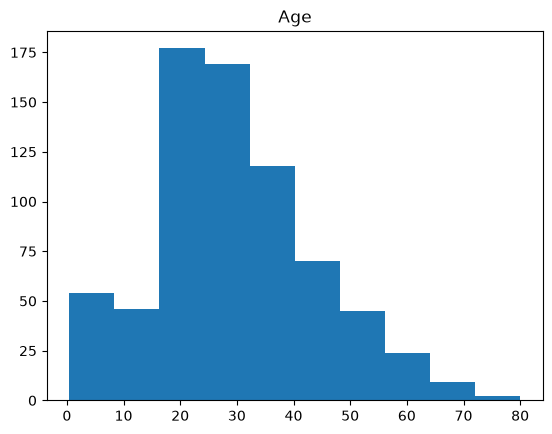

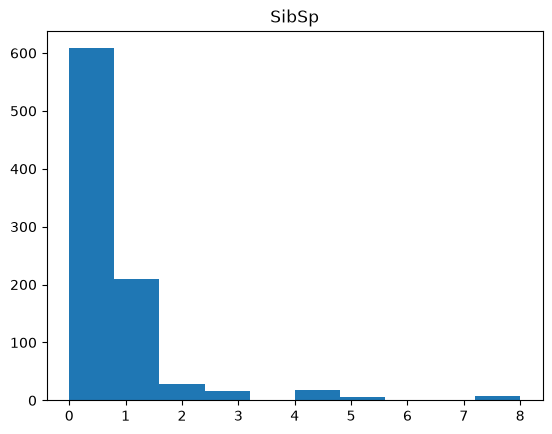

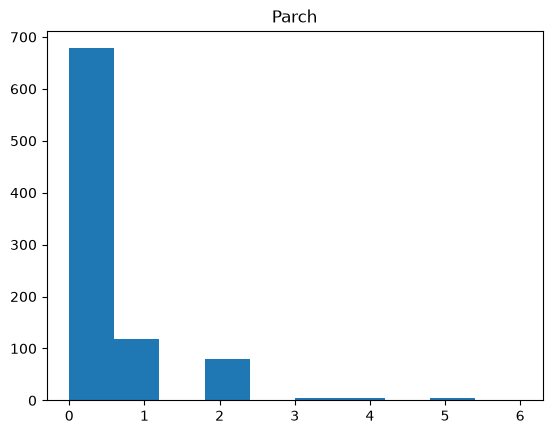

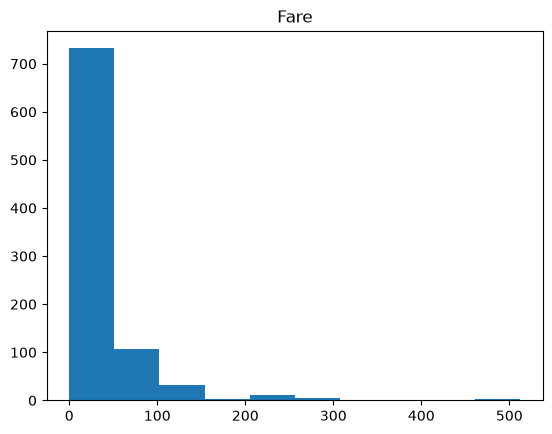

In [8]:
# distribution of numeric values
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

In [9]:
print(df_num.corr())

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


correlation = the relation between 2 numerical variables

<Axes: >

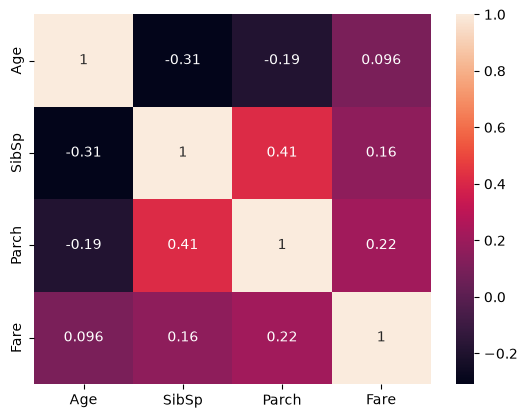

In [10]:
sns.heatmap(df_num.corr(), annot=True)

SibSp & Parch: moderate positive correlation (0.41) \
Age & SibSp: moderate negative correlation (-0.31) \
Other variables show weak or very weak correlations.

In [11]:
# compare survivale rate across Age, SibSp, Parch, and Fare
pd.pivot_table(training, index = 'Survived', values = ['Age', 'SibSp', 'Parch', 'Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


A **pivot table** groups data by a specific column and calculates summary statistics for other columns. By default, it calculates the mean.

**Conclusion**: Survivors had a higher average Fare (48.40 vs. 22.12).

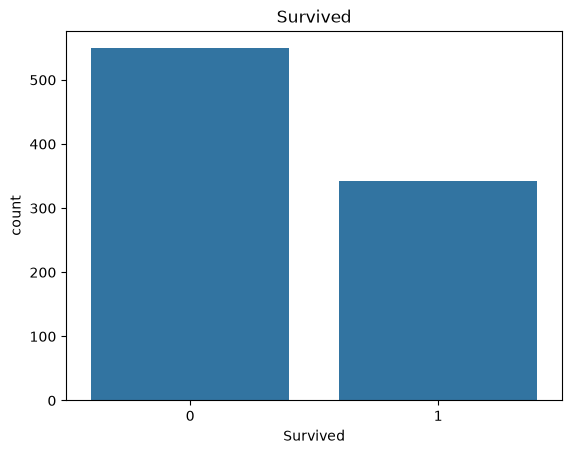

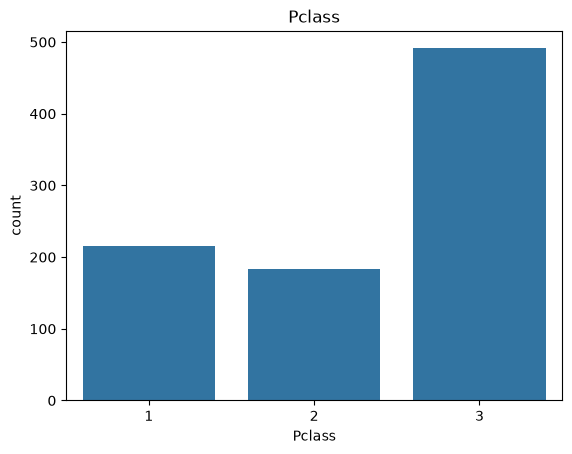

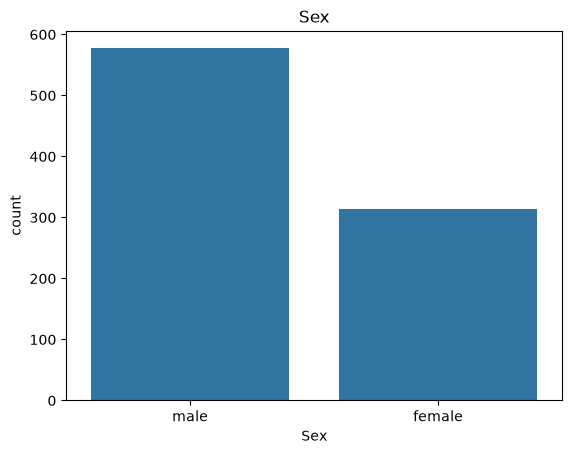

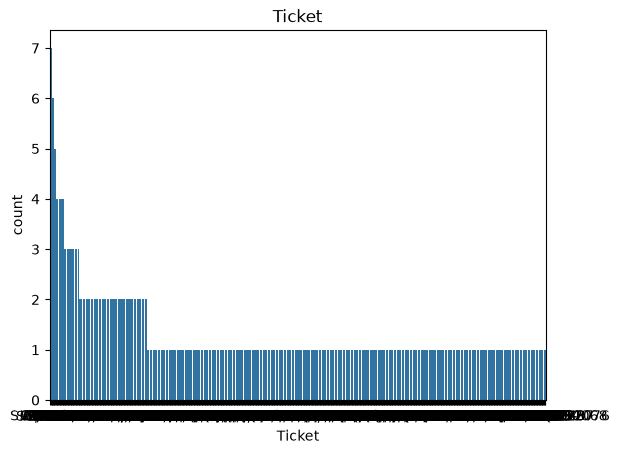

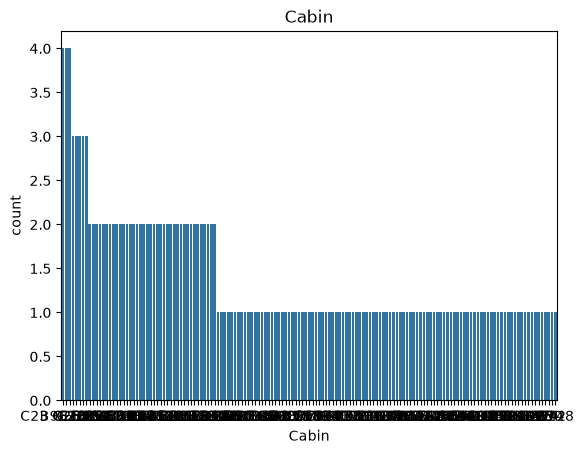

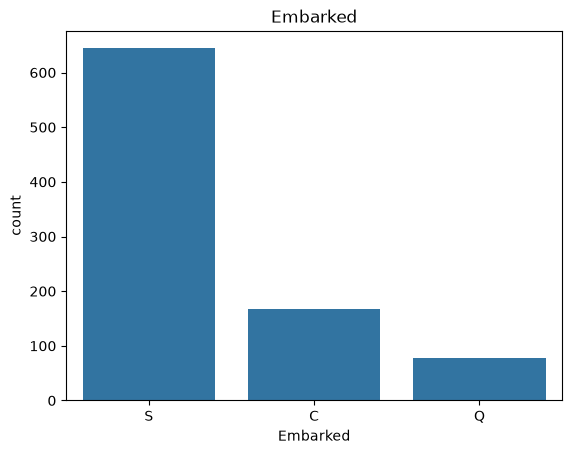

In [12]:
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index, 
                y=df_cat[i].value_counts()).set_title(i)
    plt.show()

For every categorical column, it:

1) takes the column;
2) uses .value_counts() to count each category;
3) puts categories on the X-axis;
4) puts their frequency (count) on the Y-axis;
5) creates a bar chart.

Cabin and Ticket graphs are messy

In [13]:
# comparing survivial and each categorical variable
print(pd.pivot_table(training, index = 'Survived', columns = 'Pclass', values = 'Ticket', aggfunc = 'count'))
print()

print(pd.pivot_table(training, index = 'Survived', columns = 'Sex', values = 'Ticket', aggfunc = 'count'))
print()

print(pd.pivot_table(training, index = 'Survived', columns = 'Embarked', values = 'Ticket', aggfunc = 'count'))
print()

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Sex       female  male
Survived              
0             81   468
1            233   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217



##### Feature Engineering

1) Cabin - simplify cabins (evalusted if cabin letter (cabin_adv) or the purchase of tickets across multiple cabins (cabin_miltiple) impacted survival)
2) Tickets - do different ticket types impact survivial rate
3) does the person title relate to survival rate

In [14]:
df_cat.Cabin 
training['cabin_multiple'] = training.Cabin.apply(lambda x: 0 if pd.isna(x) else len((x.split(' '))))
# after looking at this, we may to look at cabin by letter or by number.
#  Lets create some categories for this
# letters
# multiple letters
training['cabin_multiple'].value_counts()


cabin_multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

> Count how many Ticket values there are in each group.

In [15]:
pd.pivot_table(training, index = 'Survived', columns = 'cabin_multiple', values = 'Ticket', aggfunc = 'count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


> Does the number of cabins associated with a passenger's ticket have any relationship with survival?

Maybe passengers with multiple cabins were more likely to be wealthy / traveling with family / associated with certain classes.

In [16]:
# creates categories based on the first letter of the cabin (n stands for null)

# in this case we traeat the null values like its own category

training['cabin_adv'] = training.Cabin.apply(lambda x: str(x)[0])

In [17]:
# comparing survivial rate by cabin 
print(training.cabin_adv.value_counts())

pd.pivot_table(training, index = 'Survived', columns = 'cabin_adv', values = 'Name', aggfunc = 'count')

cabin_adv
n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


> How many passengers survived/died in each cabin-letter category? 

In [18]:
training[training['Cabin'].duplicated(keep=False)].sort_values('Cabin')[['Name', 'Cabin', 'Ticket', 'Survived']]

,Name,Cabin,Ticket,Survived
329,"Hippach, Miss. Jean Gertrude",B18,111361,1
523,"Hippach, Mrs. Louis Albert (Ida Sophia Fischer)",B18,111361,1
781,"Dick, Mrs. Albert Adrian (Vera Gillespie)",B20,17474,1
690,"Dick, Mr. Albert Adrian",B20,17474,1
745,"Crosby, Capt. Edward Gifford",B22,WE/P 5735,0
...,...,...,...,...
884,"Sutehall, Mr. Henry Jr",NaN,SOTON/OQ 392076,0
885,"Rice, Mrs. William (Margaret Norton)",NaN,382652,0
886,"Montvila, Rev. Juozas",NaN,211536,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,W./C. 6607,0


In [19]:
# understanding ticket values better
# numeric vs non numeric 

training['numeric_ticket'] = training.Ticket.apply(
    lambda x: 1 if x.isnumeric() else 0
    )

training['ticket_letters'] = training.Ticket.apply(
    lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() 
    if len(x.split(' ')[:-1]) > 0 else 'X'
    )

> Does the type of ticket have any relationship with survival?

In [20]:
training['numeric_ticket'].value_counts()

numeric_ticket
1    661
0    230
Name: count, dtype: int64

In [21]:
pd.set_option("display.max_rows", None)
training['ticket_letters'].value_counts()

# pd.set_option() changes how pandas displays data
# Don't limit the number of rows pandas displays. Show all rows

ticket_letters
X            665
pc            60
ca            41
a5            21
stono2        18
sotonoq       15
scparis       11
wc            10
a4             7
soc            6
c              5
fcc            5
pp             3
wep            3
sopp           3
swpp           2
ppp            2
scah           2
sotono2        2
sca4           1
sp             1
sop            1
fa             1
scow           1
sc             1
as             1
scahbasle      1
fc             1
casoton        1
Name: count, dtype: int64

In [22]:
# difference in numeric vs non numeric tickets and survival rate
pd.pivot_table(training, index='Survived', 
               columns='numeric_ticket', values='Ticket', 
               aggfunc='count')

numeric_ticket,0,1
Survived,,
0,142,407
1,88,254


In [23]:
# survival rate across different ticket types
pd.pivot_table(training, index='Survived',
               columns='ticket_letters', values='Ticket', 
               aggfunc='count')

ticket_letters,X,a4,a5,as,c,ca,casoton,fa,fc,fcc,...,soc,sop,sopp,sotono2,sotonoq,sp,stono2,swpp,wc,wep
Survived,,,,,,,,,,,,,,,,,,,,,
0,410.0,7.0,19.0,1.0,3.0,27.0,1.0,1.0,1.0,1.0,...,5.0,1.0,3.0,2.0,13.0,1.0,10.0,NaN,9.0,2.0
1,255.0,NaN,2.0,NaN,2.0,14.0,NaN,NaN,NaN,4.0,...,1.0,NaN,NaN,NaN,2.0,NaN,8.0,2.0,1.0,1.0


In [24]:
# feature engineering on person's title
training.Name.head(50)
training['name_title'] = training.Name.apply(
    lambda x: x.split(',')[1].split('.')[0].strip())
#mr. ms. master etc.

In [25]:
training['name_title'].value_counts()

name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

The names dont give the model useful general information -> because very name is unique 
\
This is feature engineering: transforming an existing column into a new feature that may contain more useful information for the ML model.
\
We're creating the feature so we can test whether different titles are associated with different survival rates.
\
example: \
Mr      → adult man \
Mrs     → married woman \
Miss    → unmarried woman / girl \
Master  → young boy \
Dr      → doctor \
Rev     → reverend/clergyman 

#### Data Preprocessing for Model

1) Drop null values from Embarked 

2) Include only relevant variables (since we have limited data, we want ot exclude things like name and passanger ID. so we can have a reasonable number of features for our models to deal with)

Variables: 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked',
       'cabin_multiple', 'cabin_adv', 'numeric_ticket','name_title'

   3)  Do categorical transforms on all data. Usually we would use a transformer, but with this approach we can ensure that our traning and test data have the same colums. We also may be able to infer something about the shape of the test data through this method. I will stress, this is generally not recommend outside of a competition (use onehot encoder)

4) Impute data with mean for fare and age (+ experiment with median)

5) Normalized fare using logarithm to give more semblance of a normal distribution

6) Scaled data 0-1 with standard scaler

a little not for my self: before we worked with training set, now we have a set combined original training and testing sets, we gonna apply feature engineering on full set then separate to train and test

In [26]:
training[training['cabin_multiple'] >= 3][
    ['Name', 'Cabin', 'Ticket', 'cabin_multiple', 'Survived']
]

,Name,Cabin,Ticket,cabin_multiple,Survived
27,"Fortune, Mr. Charles Alexander",C23 C25 C27,19950,3,0
88,"Fortune, Miss. Mabel Helen",C23 C25 C27,19950,3,1
311,"Ryerson, Miss. Emily Borie",B57 B59 B63 B66,PC 17608,4,1
341,"Fortune, Miss. Alice Elizabeth",C23 C25 C27,19950,3,1
438,"Fortune, Mr. Mark",C23 C25 C27,19950,3,0
679,"Cardeza, Mr. Thomas Drake Martinez",B51 B53 B55,PC 17755,3,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",B57 B59 B63 B66,PC 17608,4,1
872,"Carlsson, Mr. Frans Olof",B51 B53 B55,695,3,0


In [27]:
# create all categorical variable that we did above for both training and test sets
all_data['cabin_multiple'] = all_data.Cabin.apply(
    lambda x: 0 if pd.isna(x) else len(x.split(' ')))

In [28]:
all_data['cabin_adv'] = all_data.Cabin.apply(lambda x: str(x)[0])
all_data['numeric_ticket'] = all_data.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
all_data['ticket_letters'] = all_data.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() 
                                                   if len(x.split(' ')[:-1]) >0 else 0)
all_data['name_title'] = all_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

In [29]:
# impute nulls for continuous data
all_data['Age'] = all_data.Age.fillna(all_data.Age.median())
all_data['Fare'] = all_data.Fare.fillna(all_data.Fare.median())

In [30]:
# drop null 'embarked' rows. Only 2 instances of this in training set and 0 in the test set. So we can drop it
all_data.dropna(subset=['Embarked'], inplace=True)

<Axes: >

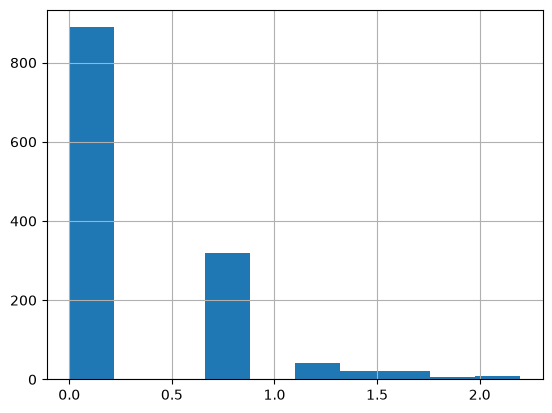

In [31]:
# tried log norm of sibsp (not used)
all_data['norm_sibsp'] = np.log(all_data.SibSp+1)
all_data['norm_sibsp'].hist()

<Axes: >

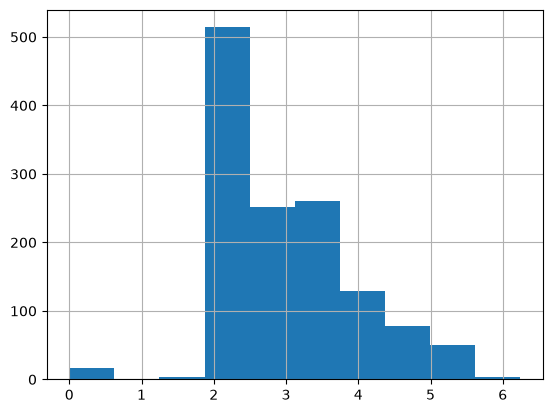

In [32]:
# log norm of fare (used)
all_data['norm_fare'] = np.log(all_data.Fare+1)
all_data['norm_fare'].hist()

In [33]:
# converted fare to category for pd.get_dummies()
all_data.Pclass = all_data.Pclass.astype(str)

In [34]:
# created dummy variable from categories (also can use OneHotEncoder)
all_dummies = pd.get_dummies(all_data[['Pclass','Sex','Age','SibSp','Parch','norm_fare','Embarked','cabin_adv','cabin_multiple','numeric_ticket','name_title','train_test']])

Dummy variables convert categorical values into separate 0/1 columns so ML models can work with them.


In [35]:
all_dummies.head()

,Age,SibSp,Parch,norm_fare,cabin_multiple,numeric_ticket,train_test,Pclass_1,Pclass_2,Pclass_3,...,name_title_Master,name_title_Miss,name_title_Mlle,name_title_Mme,name_title_Mr,name_title_Mrs,name_title_Ms,name_title_Rev,name_title_Sir,name_title_the Countess
0,22.0,1,0,2.110213,0,0,1,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1,38.0,1,0,4.280593,1,0,1,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,26.0,0,0,2.188856,0,0,1,False,False,True,...,False,True,False,False,False,False,False,False,False,False
3,35.0,1,0,3.990834,1,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,False
4,35.0,0,0,2.202765,0,1,1,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [36]:
# Split to train test sets again
X_train = all_dummies[all_dummies.train_test == 1].drop(['train_test'], axis= 1)
X_test = all_dummies[all_dummies.train_test == 0].drop(['train_test'], axis = 1)

In [37]:
y_train = all_data[all_data.train_test==1].Survived
y_train.shape

(889,)

In [38]:
y_train.head(10)

0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
5    0.0
6    0.0
7    0.0
8    1.0
9    1.0
Name: Survived, dtype: float64

In [39]:
# Scale data
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

all_dummies_scaled = all_dummies.copy()
all_dummies_scaled[['Age', 'SibSp', 'Parch', 'norm_fare']] = scale.fit_transform(
    all_dummies_scaled[['Age', 'SibSp', 'Parch', 'norm_fare']]
)

In [40]:
all_dummies_scaled.head(5)

,Age,SibSp,Parch,norm_fare,cabin_multiple,numeric_ticket,train_test,Pclass_1,Pclass_2,Pclass_3,...,name_title_Master,name_title_Miss,name_title_Mlle,name_title_Mme,name_title_Mr,name_title_Mrs,name_title_Ms,name_title_Rev,name_title_Sir,name_title_the Countess
0,-0.580261,0.480272,-0.445407,-0.896331,0,0,1,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1,0.662297,0.480272,-0.445407,1.347870,1,0,1,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,-0.269621,-0.479537,-0.445407,-0.815013,0,0,1,False,False,True,...,False,True,False,False,False,False,False,False,False,False
3,0.429318,0.480272,-0.445407,1.048255,1,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,False
4,0.429318,-0.479537,-0.445407,-0.800632,0,1,1,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [41]:

X_train_scaled = all_dummies_scaled[all_dummies_scaled.train_test == 1].drop(['train_test'], axis =1)
X_test_scaled = all_dummies_scaled[all_dummies_scaled.train_test == 0].drop(['train_test'], axis =1)

y_train = all_data[all_data.train_test==1].Survived

In [42]:
X_train.head(5)

,Age,SibSp,Parch,norm_fare,cabin_multiple,numeric_ticket,Pclass_1,Pclass_2,Pclass_3,Sex_female,...,name_title_Master,name_title_Miss,name_title_Mlle,name_title_Mme,name_title_Mr,name_title_Mrs,name_title_Ms,name_title_Rev,name_title_Sir,name_title_the Countess
0,22.0,1,0,2.110213,0,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,38.0,1,0,4.280593,1,0,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,26.0,0,0,2.188856,0,0,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
3,35.0,1,0,3.990834,1,1,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
4,35.0,0,0,2.202765,0,1,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [43]:
X_train_scaled.head(5)

,Age,SibSp,Parch,norm_fare,cabin_multiple,numeric_ticket,Pclass_1,Pclass_2,Pclass_3,Sex_female,...,name_title_Master,name_title_Miss,name_title_Mlle,name_title_Mme,name_title_Mr,name_title_Mrs,name_title_Ms,name_title_Rev,name_title_Sir,name_title_the Countess
0,-0.580261,0.480272,-0.445407,-0.896331,0,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,0.662297,0.480272,-0.445407,1.347870,1,0,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,-0.269621,-0.479537,-0.445407,-0.815013,0,0,False,False,True,True,...,False,True,False,False,False,False,False,False,False,False
3,0.429318,0.480272,-0.445407,1.048255,1,1,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
4,0.429318,-0.479537,-0.445407,-0.800632,0,1,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


##### Model Building 
-> baseline validation performance

Baseline validation is the step where you build a simple first model and measure how well it performs on data it has not seen during training.


"Let's build our first reasonable model and establish how well it performs on unseen validation data before we start optimizing anything."

Try models with default settings → measure them with cross-validation → record baseline scores → tune models → compare improvements → finally evaluate on test data.

In [44]:
from sklearn.model_selection import cross_val_score # function for evaluating a model using cross-validation.
from sklearn.naive_bayes import GaussianNB # Naive Bayes classification algorithm.
from sklearn.linear_model import LogisticRegression # a classification algorithm that predicts the probability of belonging to a class.
from sklearn import tree # decision tree classification algorithm.
from sklearn.ensemble import RandomForestClassifier # Instead of using one decision tree, Random Forest builds many trees and combines their predictions.
from sklearn.neighbors import KNeighborsClassifier # predicts a new observation based on the closest observations in the training data.
from sklearn.svm import SVC # It's a classification algorithm that tries to find a boundary that separates different classes

In [58]:
gnb = GaussianNB()
cv = cross_val_score(gnb, X_train_scaled, y_train, cv=5)
print(cv)
print("Naive Bayes CV Accuracy: ", cv.mean())

[0.66853933 0.70224719 0.75842697 0.74719101 0.73446328]
Naive Bayes CV Accuracy:  0.7221735542436362


In [45]:
lr = LogisticRegression(max_iter=2000)
cv = cross_val_score(lr, X_train, y_train, cv=5)
print(cv)
print("Logistic Regression CV Accuracy: ", cv.mean())

[0.8258427  0.80898876 0.80337079 0.82022472 0.85310734]
Logistic Regression CV Accuracy:  0.8223068621849807


In [46]:
lr = LogisticRegression(max_iter=2000)
cv = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print(cv)
print("Logistic Regression CV Accuracy: ", cv.mean())

[0.8258427  0.80898876 0.80337079 0.82022472 0.85310734]
Logistic Regression CV Accuracy:  0.8223068621849807


In [47]:
dt = tree.DecisionTreeClassifier(random_state = 1)
cv = cross_val_score(dt, X_train, y_train, cv=5)
print(cv)
print("Decision Tree CV Accuracy: ", cv.mean())

[0.75842697 0.74719101 0.8258427  0.74719101 0.8079096 ]
Decision Tree CV Accuracy:  0.7773122579826065


In [48]:
dt = tree.DecisionTreeClassifier(random_state = 1)
cv = cross_val_score(dt, X_train_scaled, y_train, cv=5)
print(cv)
print("Decision Tree CV Accuracy: ", cv.mean())

[0.75842697 0.74719101 0.8258427  0.74719101 0.8079096 ]
Decision Tree CV Accuracy:  0.7773122579826065


In [49]:
knn = KNeighborsClassifier()
cv = cross_val_score(knn, X_train, y_train, cv=5)
print(cv)
print("KNN CV Accuracy: ", cv.mean())

[0.76966292 0.79775281 0.80898876 0.82022472 0.85310734]
KNN CV Accuracy:  0.8099473116231829


In [50]:
knn = KNeighborsClassifier()
cv = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print(cv)
print("KNN CV Accuracy: ", cv.mean())

[0.79775281 0.79213483 0.83146067 0.79775281 0.85310734]
KNN CV Accuracy:  0.8144416936456548


In [51]:
rf = RandomForestClassifier(random_state=1)
cv = cross_val_score(rf, X_train, y_train, cv=5)
print(cv)
print("Random Forest CV Accuracy: ", cv.mean())

[0.80898876 0.79213483 0.84831461 0.73595506 0.82485876]
Random Forest CV Accuracy:  0.8020504030978227


In [52]:
rf = RandomForestClassifier(random_state=1)
cv = cross_val_score(rf, X_train_scaled, y_train, cv=5)
print(cv)
print("Random Forest CV Accuracy: ", cv.mean())

[0.80337079 0.79213483 0.84831461 0.73595506 0.82485876]
Random Forest CV Accuracy:  0.8009268075922046


In [53]:
svc = SVC(probability=True)
cv = cross_val_score(svc, X_train_scaled, y_train, cv=5)
print(cv)
print("SVC CV Accuracy: ", cv.mean())

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

[0.85393258 0.82022472 0.8258427  0.80337079 0.86440678]
SVC CV Accuracy:  0.8335555132355742


In [54]:
from xgboost import XGBClassifier


In [55]:
xgb = XGBClassifier(random_state=1)
cv = cross_val_score(xgb, X_train_scaled, y_train, cv=5)
print(cv)
print("XGB CV Accuracy: ", cv.mean())

[0.81460674 0.80898876 0.86516854 0.79775281 0.81920904]
XGB CV Accuracy:  0.8211451786961215


Voting classifier takes all of the inputs and averages the results. For a "hard" voting classifier each classifier gets 1 vote "yes" or "no" and the result is just a popular vote. For this, you generally want odd numbers \
\
A "soft" classifier averages the confidence of each of the models. If a the average confidence is > 50% that it is a 1 it will be counted as such

In [56]:
from sklearn.ensemble import VotingClassifier

In [59]:
voting_clf = VotingClassifier(estimators=[('lr', lr), ('dt', dt), ('knn', knn), ('rf', rf), ('gnb', gnb), ('svc', svc), ('xgb', xgb)], voting='soft')


In [60]:
cv = cross_val_score(voting_clf, X_train_scaled, y_train, cv = 5)
print(cv)
print(cv.mean())

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

[0.82022472 0.82022472 0.83146067 0.79775281 0.8700565 ]
0.8279438837046911


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [65]:
voting_clf.fit(X_train_scaled, y_train)
y_hat_base_vc = voting_clf.predict(X_test_scaled).astype(int)
basic_submisson = {'PassengerId': testing.PassengerId, 'Survived': y_hat_base_vc}
base_submission = pd.DataFrame(data=basic_submisson)
base_submission.to_csv('base_submission.csv', index=False)

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Model Building (Baseline Validation Performance)

Naive Bayes (72.2%)  \
Logistic Regression (82.2%) \
Decision Tree (77.7%) \
K Nearest Neighbor (81.4%) \
Random Forest (80.2%) \
Support Vector Classifier (83.3%) \
Xtreme Gradient Boosting (82.1%) \
Soft Voting Classifier - All Models (82.8%) \

#### Mode Tunning

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

: GridSearchCV tries different combinations of hyperparameters, evaluates each using cross-validation, and keeps the combination with the best score.

In [71]:
def clf_performance(classifier, model_name): 
    print(model_name)
    print('Best Score: ' + str(classifier.best_score_))
    print('Best parameters: ' + str(classifier.best_params_) )

the classifier is already-fitted gridsearch object \ 
the best_params gives the hyperparameter combination that produced that score.

In [72]:
lr = LogisticRegression()

param_grid = {'max_iter': [2000], 
              'penalty' : ['l1', 'l2'], 
              'C' : np.logspace(-4, 4, 20), 
              'solver' : ['liblinear']}

clf_lr = GridSearchCV(lr, param_grid= param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_lr = clf_lr.fit(X_train_scaled, y_train)
clf_performance(best_clf_lr, 'LogisticRegression')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
LogisticRegression
Best Score: 0.8279375357074843
Best parameters: {'C': np.float64(1.623776739188721), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [73]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9],
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto', 'ball_tree','kd_tree'],
              'p' : [1,2]}
clf_knn = GridSearchCV(knn, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_knn = clf_knn.fit(X_train_scaled,y_train)
clf_performance(best_clf_knn,'KNN')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN
Best Score: 0.8290611312131023
Best parameters: {'algorithm': 'ball_tree', 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


In [74]:
svc = SVC(probability = True)
param_grid = tuned_parameters = [{'kernel': ['rbf'], 'gamma': [.1,.5,1,2,5,10],
                                  'C': [.1, 1, 10, 100, 1000]},
                                 {'kernel': ['linear'], 'C': [.1, 1, 10, 100, 1000]},
                                 {'kernel': ['poly'], 'degree' : [2,3,4,5], 'C': [.1, 1, 10, 100, 1000]}]
clf_svc = GridSearchCV(svc, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_svc = clf_svc.fit(X_train_scaled,y_train)
clf_performance(best_clf_svc,'SVC')

Fitting 5 folds for each of 55 candidates, totalling 275 fits


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC
Best Score: 0.8335555132355742
Best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [75]:
rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [400,450,500,550],
               'criterion':['gini','entropy'],
                                  'bootstrap': [True],
                                  'max_depth': [15, 20, 25],
                                  'max_features': ['auto','sqrt', 10],
                                  'min_samples_leaf': [2,3],
                                  'min_samples_split': [2,3]}
                                  
clf_rf = GridSearchCV(rf, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_rf = clf_rf.fit(X_train_scaled,y_train)
clf_performance(best_clf_rf,'Random Forest')

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
480 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
381 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
  File "c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\base.py", line 554, in _validate_params
    validat

Random Forest
Best Score: 0.8358027042468101
Best parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 15, 'max_features': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 550}


<Axes: >

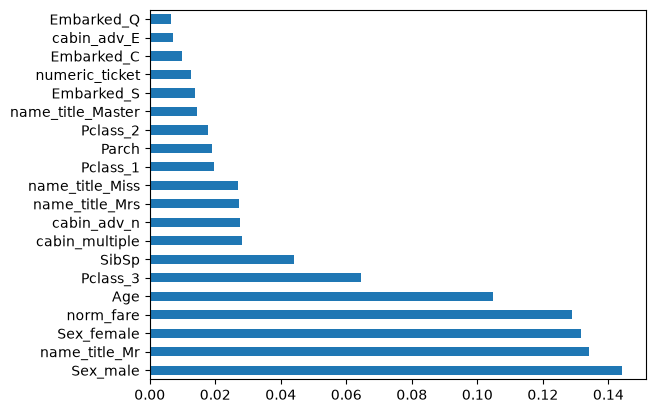

In [76]:
best_rf = best_clf_rf.best_estimator_.fit(X_train_scaled,y_train)
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns)
feat_importances.nlargest(20).plot(kind='barh')

In [77]:
xgb = XGBClassifier(random_state = 1)

param_grid = {
    'n_estimators': [450,500,550],
    'colsample_bytree': [0.75,0.8,0.85],
    'max_depth': [None],
    'reg_alpha': [1],
    'reg_lambda': [2, 5, 10],
    'subsample': [0.55, 0.6, .65],
    'learning_rate':[0.5],
    'gamma':[.5,1,2],
    'min_child_weight':[0.01],
    'sampling_method': ['uniform']
}

clf_xgb = GridSearchCV(xgb, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_xgb = clf_xgb.fit(X_train_scaled,y_train)
clf_performance(best_clf_xgb,'XGB')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
XGB
Best Score: 0.8504030978226369
Best parameters: {'colsample_bytree': 0.85, 'gamma': 1, 'learning_rate': 0.5, 'max_depth': None, 'min_child_weight': 0.01, 'n_estimators': 450, 'reg_alpha': 1, 'reg_lambda': 2, 'sampling_method': 'uniform', 'subsample': 0.6}


In [79]:
y_hat_xgb = best_clf_xgb.best_estimator_.predict(X_test_scaled).astype(int)
xgb_submission = {'PassengerId': testing.PassengerId, 'Survived': y_hat_xgb}
submission_xgb = pd.DataFrame(data=xgb_submission)
submission_xgb.to_csv('xgb_submission3.csv', index=False)

Model Additional Ensemble Approaches
1) Experimented with a hard voting classifier of three estimators (KNN, SVM, RF) (81.6%)

2) Experimented with a soft voting classifier of three estimators (KNN, SVM, RF) (82.3%) (Best Performance)

3) Experimented with soft voting on all estimators performing better than 80% except xgb (KNN, RF, LR, SVC) (82.9%)

4) Experimented with soft voting on all estimators including XGB (KNN, SVM, RF, LR, XGB) (83.5%)

In [80]:
best_lr = best_clf_lr.best_estimator_
best_knn = best_clf_knn.best_estimator_
best_svc = best_clf_svc.best_estimator_
best_rf = best_clf_rf.best_estimator_
best_xgb = best_clf_xgb.best_estimator_

voting_clf_hard = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'hard') 
voting_clf_soft = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'soft') 
voting_clf_all = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc), ('lr', best_lr)], voting = 'soft') 
voting_clf_xgb = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc), ('xgb', best_xgb),('lr', best_lr)], voting = 'soft')

print('voting_clf_hard :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5))
print('voting_clf_hard mean :',cross_val_score(voting_clf_hard,X_train,y_train,cv=5).mean())

print('voting_clf_soft :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5))
print('voting_clf_soft mean :',cross_val_score(voting_clf_soft,X_train,y_train,cv=5).mean())

print('voting_clf_all :',cross_val_score(voting_clf_all,X_train,y_train,cv=5))
print('voting_clf_all mean :',cross_val_score(voting_clf_all,X_train,y_train,cv=5).mean())

print('voting_clf_xgb :',cross_val_score(voting_clf_xgb,X_train,y_train,cv=5))
print('voting_clf_xgb mean :',cross_val_score(voting_clf_xgb,X_train,y_train,cv=5).mean())

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

voting_clf_hard : [0.79213483 0.81460674 0.82022472 0.79775281 0.83615819]


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

voting_clf_hard mean : 0.8121754586427983


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

...

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  war

voting_clf_xgb : [0.80898876 0.8258427  0.83146067 0.80337079 0.85875706]


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  war

voting_clf_xgb mean : 0.8268075922046594


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [81]:
params = {'weights' : [[1,1,1],[1,2,1],[1,1,2],[2,1,1],[2,2,1],[1,2,2],[2,1,2]]}

vote_weight = GridSearchCV(voting_clf_soft, param_grid = params, cv = 5, verbose = True, n_jobs = -1)
best_clf_weight = vote_weight.fit(X_train_scaled,y_train)
clf_performance(best_clf_weight,'VC Weights')
voting_clf_sub = best_clf_weight.best_estimator_.predict(X_test_scaled)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
VC Weights
Best Score: 0.83244461372437
Best parameters: {'weights': [2, 2, 1]}


c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [82]:
#Make Predictions 
voting_clf_hard.fit(X_train_scaled, y_train)
voting_clf_soft.fit(X_train_scaled, y_train)
voting_clf_all.fit(X_train_scaled, y_train)
voting_clf_xgb.fit(X_train_scaled, y_train)

best_rf.fit(X_train_scaled, y_train)
y_hat_vc_hard = voting_clf_hard.predict(X_test_scaled).astype(int)
y_hat_rf = best_rf.predict(X_test_scaled).astype(int)
y_hat_vc_soft =  voting_clf_soft.predict(X_test_scaled).astype(int)
y_hat_vc_all = voting_clf_all.predict(X_test_scaled).astype(int)
y_hat_vc_xgb = voting_clf_xgb.predict(X_test_scaled).astype(int)

c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\diana\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'pena

In [84]:
#convert output to dataframe 
final_data = {'PassengerId': testing.PassengerId, 'Survived': y_hat_rf}
submission = pd.DataFrame(data=final_data)

final_data_2 = {'PassengerId': testing.PassengerId, 'Survived': y_hat_vc_hard}
submission_2 = pd.DataFrame(data=final_data_2)

final_data_3 = {'PassengerId': testing.PassengerId, 'Survived': y_hat_vc_soft}
submission_3 = pd.DataFrame(data=final_data_3)

final_data_4 = {'PassengerId': testing.PassengerId, 'Survived': y_hat_vc_all}
submission_4 = pd.DataFrame(data=final_data_4)

final_data_5 = {'PassengerId': testing.PassengerId, 'Survived': y_hat_vc_xgb}
submission_5 = pd.DataFrame(data=final_data_5)

final_data_comp = {'PassengerId': testing.PassengerId, 'Survived_vc_hard': y_hat_vc_hard, 'Survived_rf': y_hat_rf, 'Survived_vc_soft' : y_hat_vc_soft, 'Survived_vc_all' : y_hat_vc_all,  'Survived_vc_xgb' : y_hat_vc_xgb}
comparison = pd.DataFrame(data=final_data_comp)

In [85]:
#track differences between outputs 
comparison['difference_rf_vc_hard'] = comparison.apply(lambda x: 1 if x.Survived_vc_hard != x.Survived_rf else 0, axis =1)
comparison['difference_soft_hard'] = comparison.apply(lambda x: 1 if x.Survived_vc_hard != x.Survived_vc_soft else 0, axis =1)
comparison['difference_hard_all'] = comparison.apply(lambda x: 1 if x.Survived_vc_all != x.Survived_vc_hard else 0, axis =1)

In [86]:
comparison.difference_hard_all.value_counts()


difference_hard_all
0    410
1      8
Name: count, dtype: int64

In [87]:
#prepare submission files 
submission.to_csv('submission_rf.csv', index =False)
submission_2.to_csv('submission_vc_hard.csv',index=False)
submission_3.to_csv('submission_vc_soft.csv', index=False)
submission_4.to_csv('submission_vc_all.csv', index=False)
submission_5.to_csv('submission_vc_xgb2.csv', index=False)